<img src="logo_UNSAM.jpg" align="right" width="150">

#### Análisis y Procesamiento de Señales

# *TS1 - Síntesis de señales*

### *Autora: Catalina Gonzalez Araujo*

### *Docentes: Mariano Llamedo Soria, David Ezequiel Benoit, Francisco Hernan Ledesma.*

# <u>**Introducción teórica**</u>

Una señal puede caracterizarse mediante parámetros como: 
- *Amplitud*: valor máximo de la onda.
- *Frecuencia*: número de ciclos por segundo.
- *Fase*: desplazamiento de la onda respecto al origen.
- *Energía y potencia*: magnitudes que me permiten medir la intensidad de la señal.

En el presente informe se trabajó con distintos tipos de señales, como **señales sinusoidales**, que son periódicas y pueden descomponerse en una suma de senos (*Transformada de Fourier*). Variando los parámetros de la señal sinusoidal, se observó como se comportan las señales en diferentes condiciones. 

Otras señales analizadas fueron las **cuadradas** y los **pulsos rectangulares**.

Finalmente se calculó el producto de convolución entre distintas señales de entrada $x[n]$ y la respuesta al impulso $h[n] = \delta [n] - \delta [n - 4]$, obteniendo asi la salida correspondiente a cada caso $y[n]$.

#### <u>Observación:</u> 
- Se calculó la energía ($E = \sum x^2[n]$) o potencia (${potencia} = \frac{(amplitud)^2}{2}$) según corresponda, de todas las señales analizadas. La potencia para señales periódicas y de duración finita, y la energía para señales no periódicas y de duración finita.
  
- En todos los casos se siguió el teorema de *Nyquist-Shannon*, el cual establece la frecuencia mínima necesaria para muestrear una señal analógica y poder reconstruirla de forma precisa sin perder información, esta debe ser al menos el doble de la frecuencia máxima de la señal. Este valor mínimo es: $fs \ge {frecuencia}$. Conociendo este teorema, se estimó la frecuencia de muestreo probando distintos valores hasta que la función se graficaba correctamentee. 

# <u>**Análisis y desarrollo**</u>

A continuación, se detallan los procedimientos realizados para cumplir con las consignas propuestas por la cátedra, junto con un análisis de cada resultado obtenido.

1) <font color=red><u> **Síntesis y gráfico de señales</u><font>**

Para la realizacion de los siguientes items, cree un archivo llamado *Funciones* en el cuaal se encuentran todas las funciones que crean las distintas señales a graficar. A continuacion adjunto el codigo con esas funciones.

In [64]:
# Primero importo la libreria numpy
import numpy as np
from scipy import signal

# Defino mis funciones
# Funcion de una señal sinusoidal
def mi_funcion_sen(amplitud = 1, offset = 0, frecuencia = 1, fase = 0, N = 1000, fs = 1000):
    """
    - amplitud: es la amplitud maxima. [amplitud] = [V]
    - offset: es mi amplitud media. [offset] = [V]
    - frecuencia: es la frecuencia de la señal. [frecuencia] = [Hz]
    - fase: es la fase inicial. [fase] = [rad]
    - N: es la cantidad de muestras a generar
    - fs: es la frecuencia de muestreo del ADC. [fs] = [Hz]
    """
    Ts = 1/fs # Es el tiempo en el cual se toma cada muestra

    tt = np.arange(start = 0, stop= N*Ts, step = Ts)

    xx = amplitud * np.sin(2 * np.pi * frecuencia * tt + fase) + offset

    return tt, xx

# Funcion de una señal sinusoidal modulada en amplitud por otra señal sinusoidal de la mitad de frecuencia
def mi_funcion_sen_modulada(amplitud = 1, offset = 0, frecuencia = 1, fase = 0, N = 1000, fs = 1000):
   
    Ts = 1/fs # Es el tiempo en el cual se toma cada muestra

    tt = np.arange(start = 0, stop= N*Ts, step = Ts)

    xx = amplitud * np.sin(2 * np.pi * frecuencia * tt + fase) * np.sin(2 * np.pi * frecuencia/2 * tt + fase) + offset

    return tt, xx

# Funcion para redcortar una funcion al 75% de su amplitud
def mi_funcion_sen_recortada(amplitud = 1, offset = 0, frecuencia = 1, fase = 0, N = 1000, fs = 1000):
    
    Ts = 1/fs # Es el tiempo en el cual se toma cada muestra

    tt = np.arange(start = 0, stop= N*Ts, step = Ts)

    xx = amplitud * np.sin(2 * np.pi * frecuencia * tt + fase) + offset

    valor_corte = amplitud * 0.75 # es el 75% de la amplitud
    
    xx = np.clip(xx, - valor_corte, valor_corte) # Funcion de numpy que me recorta la señal
    
    return tt, xx

# Funcion para una señal cuadrada
def mi_funcion_cuadrada (frecuencia, fs, N, offset, fase):
    Ts = 1/fs # Es el tiempo en el cual se toma cada muestra

    ttc = np.arange(start = 0, stop= N*Ts, step = Ts)

    xxc = signal.square(2 * np.pi * frecuencia * ttc + fase) + offset

    return ttc, xxc

# Funcion para un pulso
def mi_funcion_pulso (t0, tf, N, h):
    """
    t0: tiempo donde empieza el pulso
    tf: hasta donde 
    N: cantidad de muestras
    h: altura

    """
    
    x = np.zeros(N)
    x[t0:tf] = h
    
    print(f"\nPULSO RECTANGULAR DE 10ms\n{x}")
    
    return x

# Funcion para calcular la potencia de una señal
def calcular_potencia(x):
    return np.mean(x**2)

# Funcion para calcular la energia de una señal
def calcular_energia(x):
    return np.sum(x**2)

<font color=green>**1.** *Señal sinusoidal de 2kHz*<font> 

En esta experiencia se graficó una señal sinusoidal con una frecuencia de 2*kHz*. Siguiendo el teorema de *Nyquist-Shannon*, se configuró una frecuencia de muestreo de 40*kHz* = 40000*Hz*. Al graficarla en el dominio temporal con el paso de muestras elegido ($N = 100$), se observó que esta señal presenta un comportamiento periódico y continuo. 

Luego, se calculó la potencia, la cual coincide con la esperada para una señal sinusoidal de *amplitud = 1* (${potencia} = \frac{1}{2} = 0.5$).

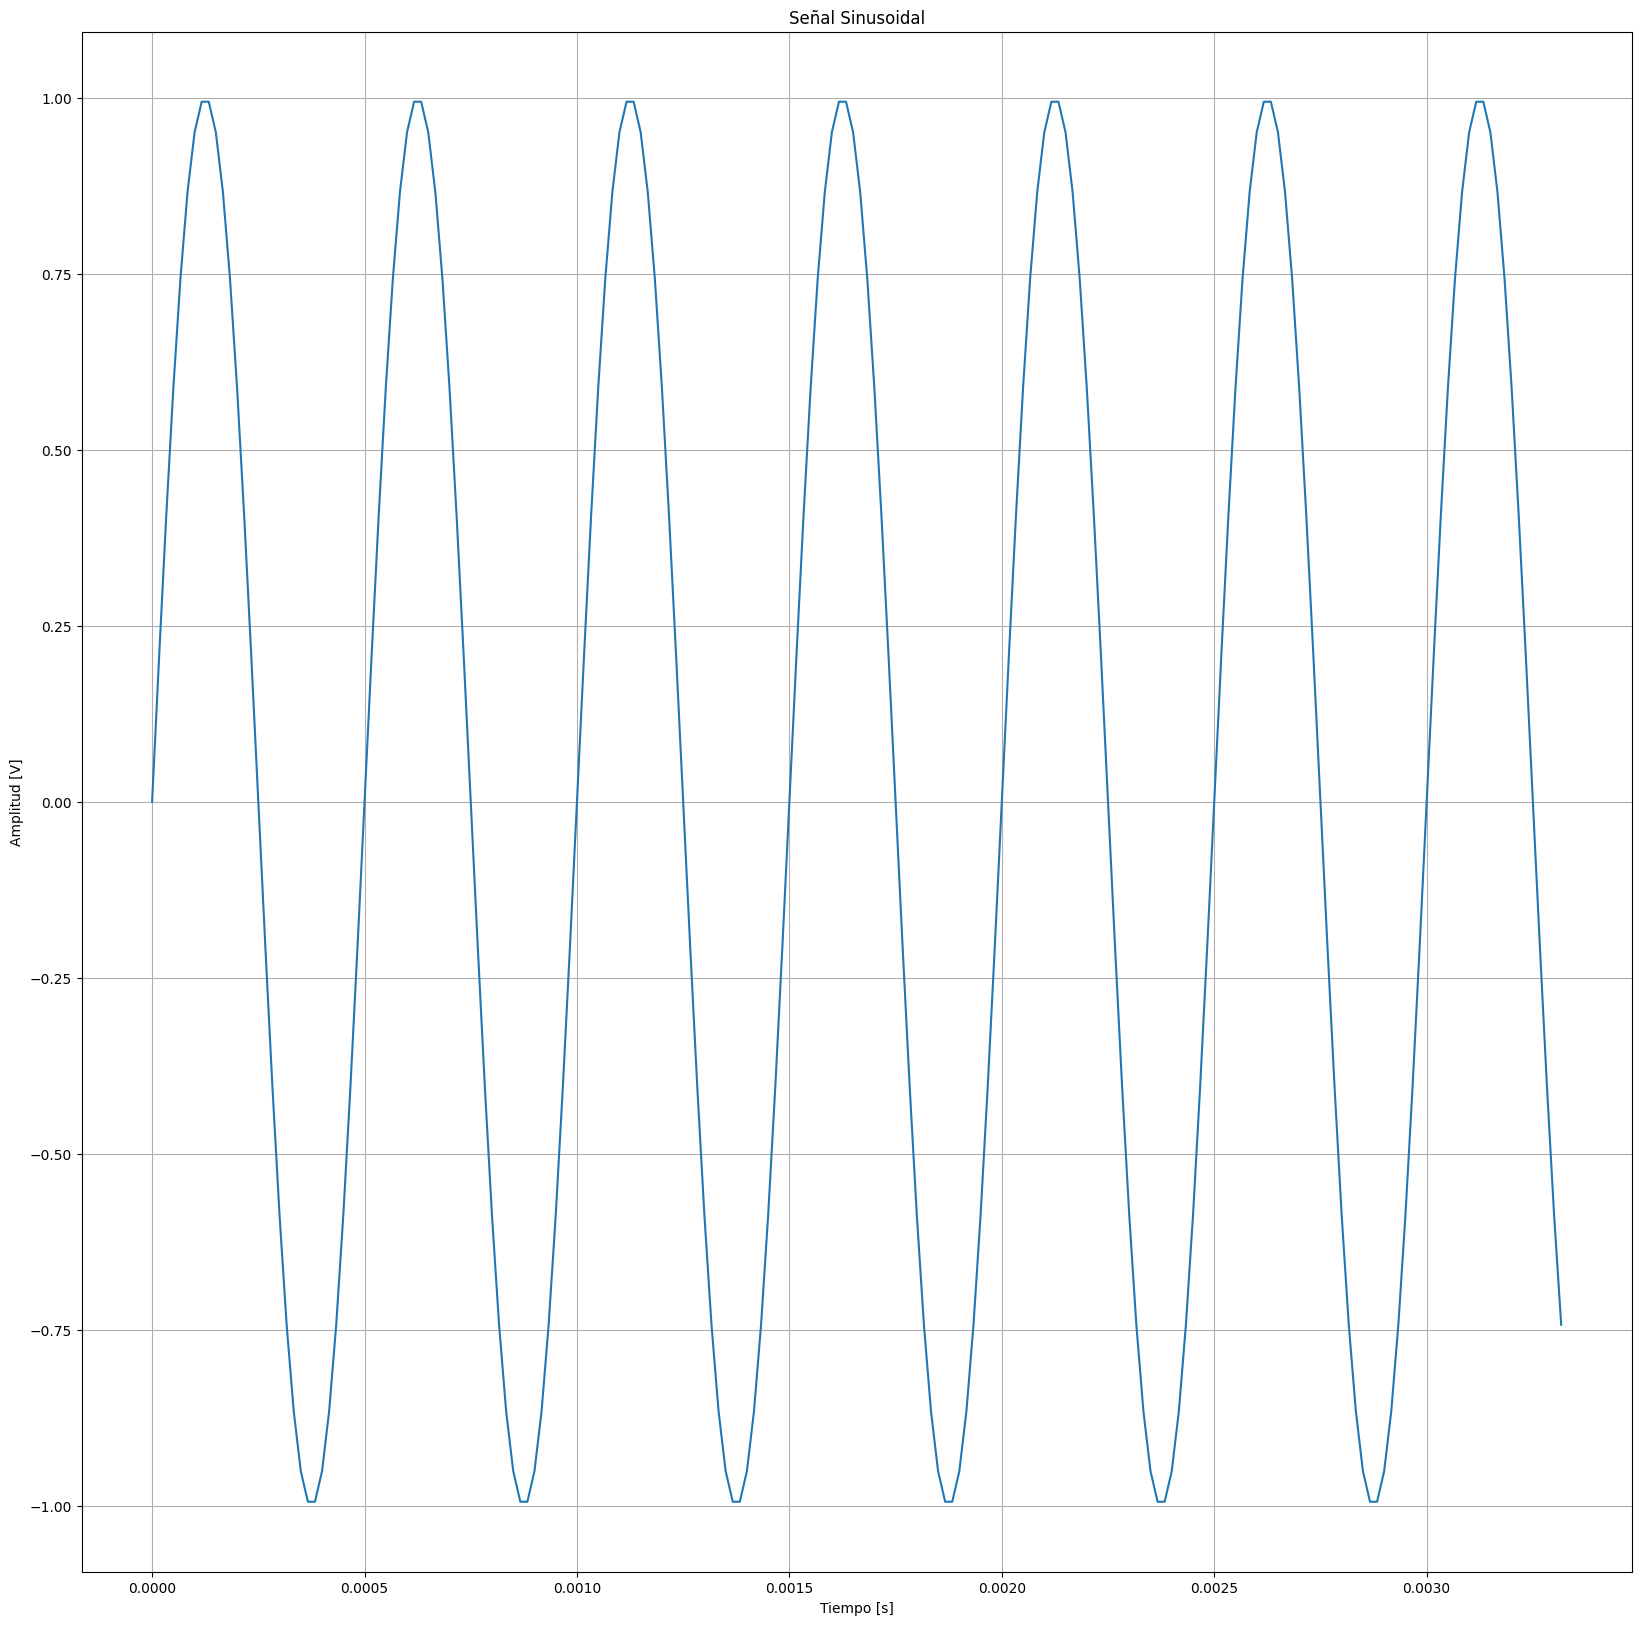

El tiempo entre muestras es 1.6666666666666667e-05 segundos
Potencia de la señal f1:  0.4930320885122282


In [65]:
# Importo la libreria para poder graficar
import matplotlib.pyplot as plt

# ------------------------------- ITEM 1 -------------------------------
# Señal sinusoidal de 2kHz 
# Defino mis variables 
amplitud = 1
offset = 0
frecuencia = 2000 # 2kHz = 2000 Hz
fase = 0
N = 200 # Cantidad de muestras
fs = 60000 # Pongo fs > 2 * frecuencia --> Teorema de Nyquist-Shannon
# Con esa fs se cumple Nyquist y las señales se ven suaves

# Llamo a mi funcion
_,f1 = mi_funcion_sen(amplitud, offset, frecuencia, fase, N, fs)

# Genero otra ventana para los graficos
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.title("Señal Sinusoidal")

# Grafico la señal senoidal de 2KHz
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.plot(_,f1)
plt.grid()
plt.show()

# TIEMPO ENTRE MUESTRAS
Ts = 1/fs
print(f"El tiempo entre muestras es {Ts} segundos")

# Calculo la potenacia
x = calcular_potencia(f1)
print("Potencia de la señal f1: ", x)

<font color=green>**2.** *Señal amplificada y desfazada en $\frac{\pi}{2}$*<font>

En esta oportunidad, se graficó la misma señal pero con mayor amplitud, y un desfase de $\frac{\pi}{2}$, el resto de los parámetros de la función de la señal senoidal son los mismos que para la graficada anteriormente. 

Al aumentar la amplitud, se incrementa la amplitud máxima respecto de la señal original, y el desfase provoca un desplazamiento temporal de un cuarto de periodo.

Es coherente que en este caso, la potencia sea mayor que en la sinusoidal base, ya que aumentamos el factor de amplificación.

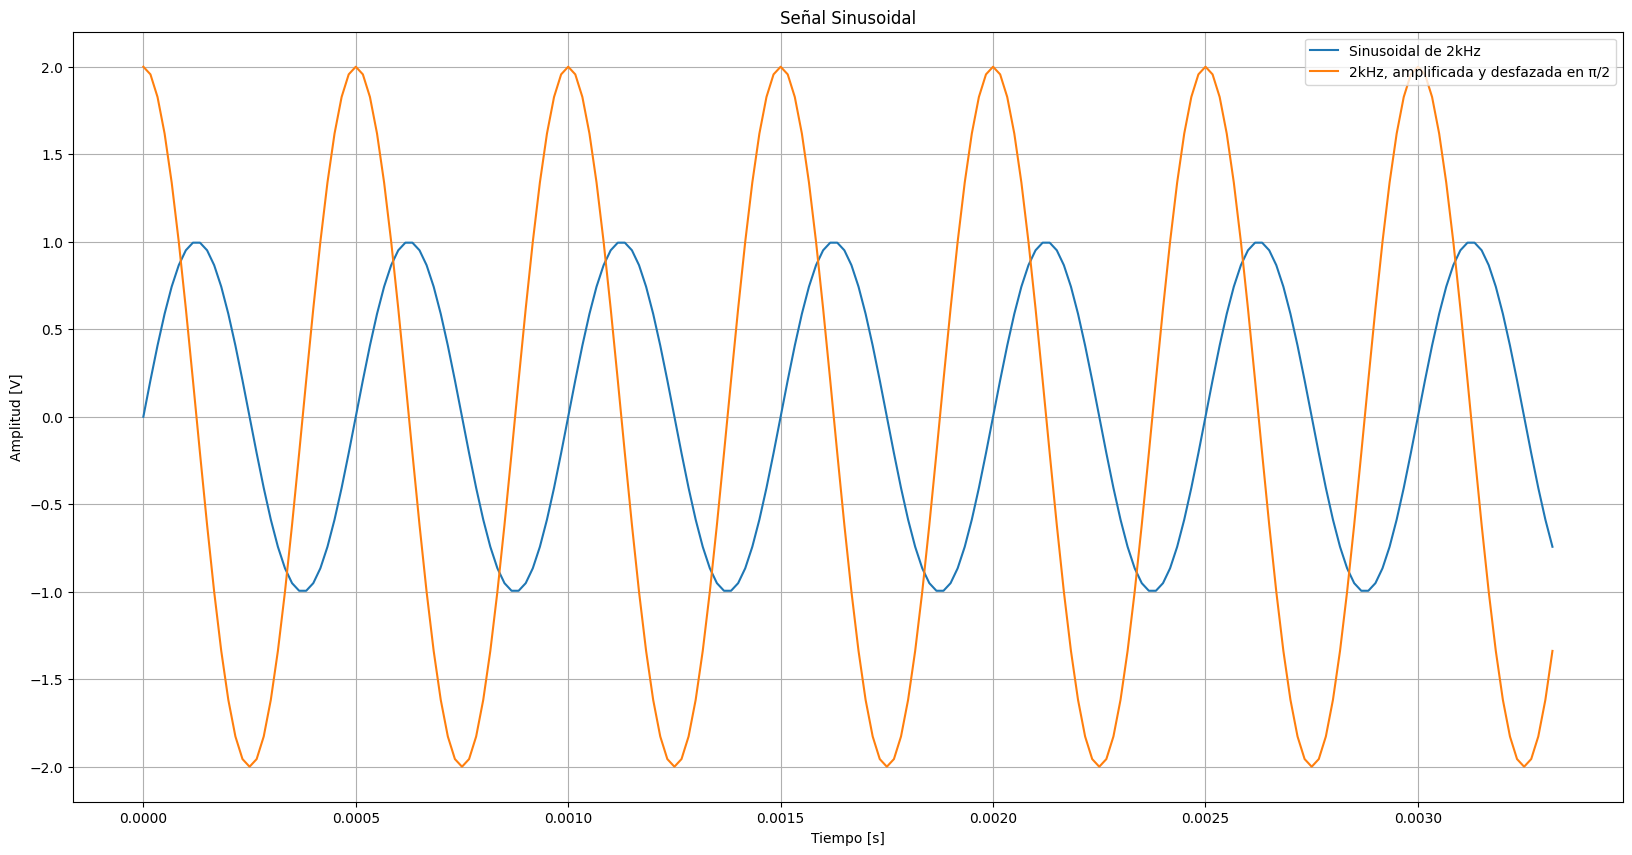

El tiempo entre muestras es 1.6666666666666667e-05 segundos
Potencia de la señal f2:  2.027871645951087


In [66]:
# ------------------------------- ITEM 2 -------------------------------
# Señal sinusoidal de 2kHz, amplificada y desfazada en pi/2 
# Defino mis variables 
amplitud = 2
offset = 0
frecuencia = 2000 # 2kHz = 2000 Hz
fase = np.pi/2
N = 200 # Cantidad de muestras
fs = 60000

# Llamo a mi funcion
_,f2 = mi_funcion_sen(amplitud, offset, frecuencia, fase, N, fs) 

# Grafico la señal senoidal de 2KHz, pero amplificada y desfazada en pi/2
plt.figure(figsize = (20, 10))
plt.title("Señal Sinusoidal")

# Grafico la señal senoidal de 2KHz
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.plot(_,f1,  label = 'Sinusoidal de 2kHz')
plt.legend()

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
# plt.plot(_,f2, 'x:', label = f'2kHz, amplificada y desfazada en {fase}')
plt.plot(_,f2, label = '2kHz, amplificada y desfazada en π/2')
plt.legend()
plt.grid()
plt.show()

# TIEMPO ENTRE MUESTRAS
Ts = 1/fs
print(f"El tiempo entre muestras es {Ts} segundos")

# Calculo la potenacia
x = calcular_potencia(f2)
print("Potencia de la señal f2: ", x)

<font color=green>**3.** *Señal modulada en amplitud por otra señal sinusoidal de 1kHz*<font>

Modular en amplitud una señal consiste en hacer que la amplitud de la señal original varíe en el tiempo de acuerdo con una señal modulante. 

En este ítem se realizó la modulación en amplitud de una señal sinusoidal (señal original) utilizando otra señal sinusoidal de la mitad de su frecuencia (*1kHz*) como modulante. 

Se realizó el producto entre ambas señales, y luego se graficó el resultado de esa señal modulada. El resultado es una nueva señal cuya envolvente sigue la forma de onda de la señal original. 

Se observa en el gráfico que la amplitud de la señal modulada crece y decrece con la frecuencia de la señal original. 

La potencia en este caso es intermedia, depende de la amplitud de la señal original y la modulada.

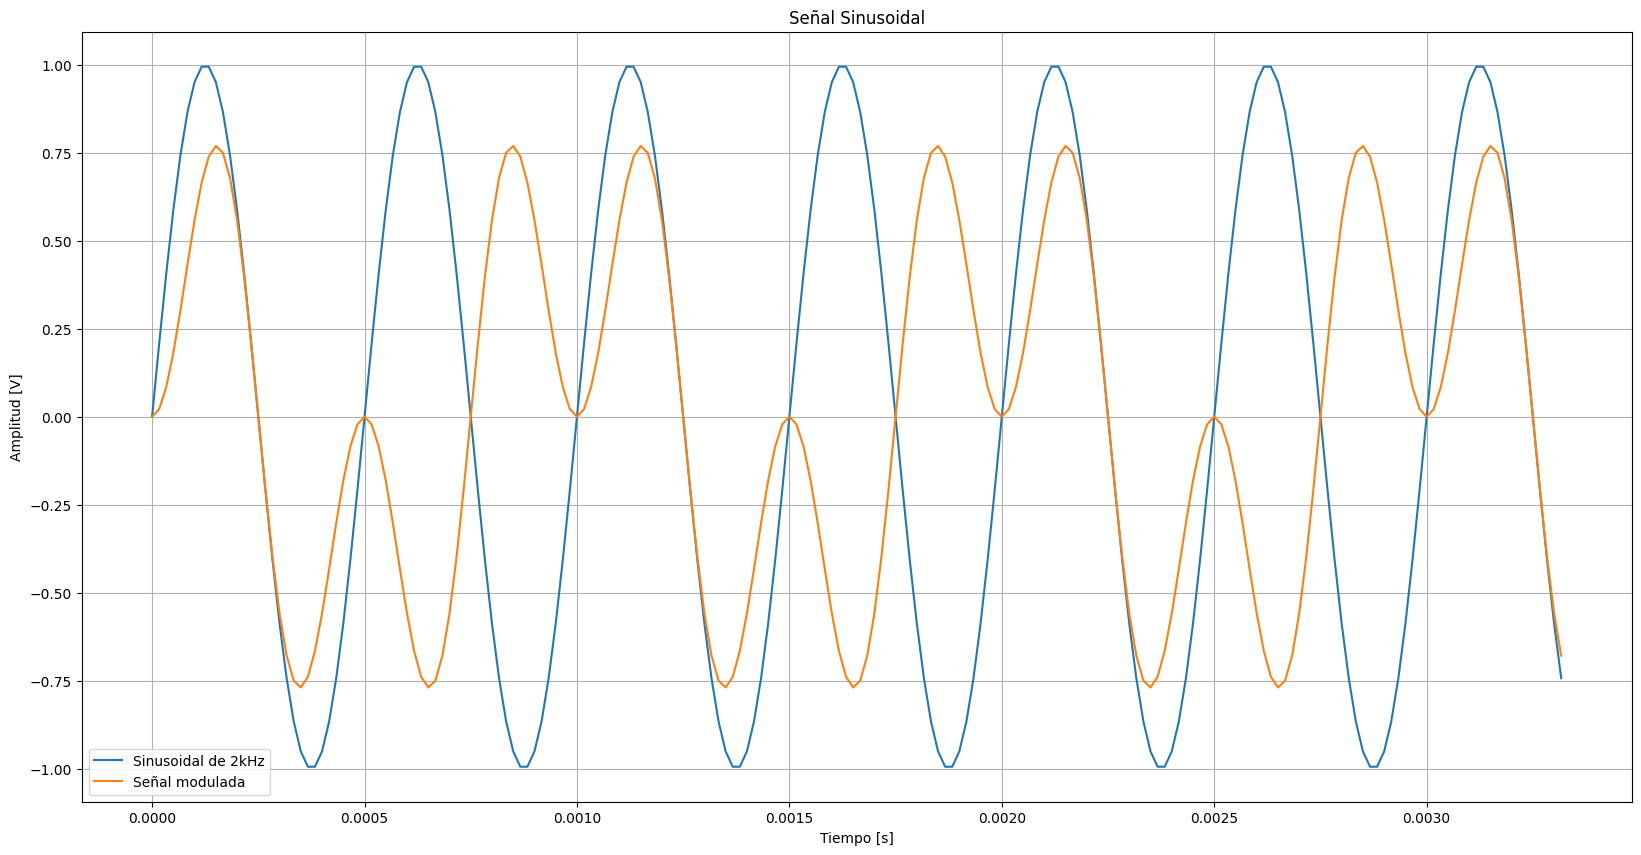

El tiempo entre muestras es 1.6666666666666667e-05 segundos
Potencia de la señal f3:  0.24862219466805802


In [67]:
# ------------------------------- ITEM 3 -------------------------------
# Señal sinusoidal modulada por otra señal sinusoidal de 1kHz 
# Defino mis variables
amplitud = 1
offset = 0
frecuencia = 2000 # 2kHz = 2000 Hz
fase = 0
N = 200 # Cantidad de muestras
fs = 60000

# Llamo a mi funcion
_,f3 = mi_funcion_sen_modulada(amplitud, offset, frecuencia, fase, N, fs)

# Grafico la señal senoidal de 2KHz, pero modulada por otra señal de la mitad de la frecuencia
plt.figure(figsize = (20, 10))
plt.title("Señal Sinusoidal")

# Grafico la señal senoidal de 2KHz
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.plot(_,f1,  label = 'Sinusoidal de 2kHz')
plt.legend()

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.plot(_, f3, label = 'Señal modulada') # Genero el grafico de la señal
plt.legend()
plt.grid()
plt.show()

# TIEMPO ENTRE MUESTRAS
Ts = 1/fs
print(f"El tiempo entre muestras es {Ts} segundos")

# Calculo la potenacia
x = calcular_potencia(f3)
print("Potencia de la señal f3: ", x)

<font color=green>**4.** *Señal recortada al 75% de su amplitud*<font>

El recorte de una señal sinusoidal produce que la forma de onda pierda suavidad, y aparecen picos planos en la envolvente. 

Recortar es aplicarle una limitación a la señal, es decir que cuando esta alcanza un cierto valor máximo (el 75% de la amplitud en este caso: $\frac{75 \cdot 1}{100} = 0.75$), todo lo que excede ese valor se "corta" y queda fijo ese límite hasta que la señal ya no supere ese valor y vuelva a sus valores originales. 

La potencia disminuye respecto a la señal original debido a que su amplitud efectiva disminuye.

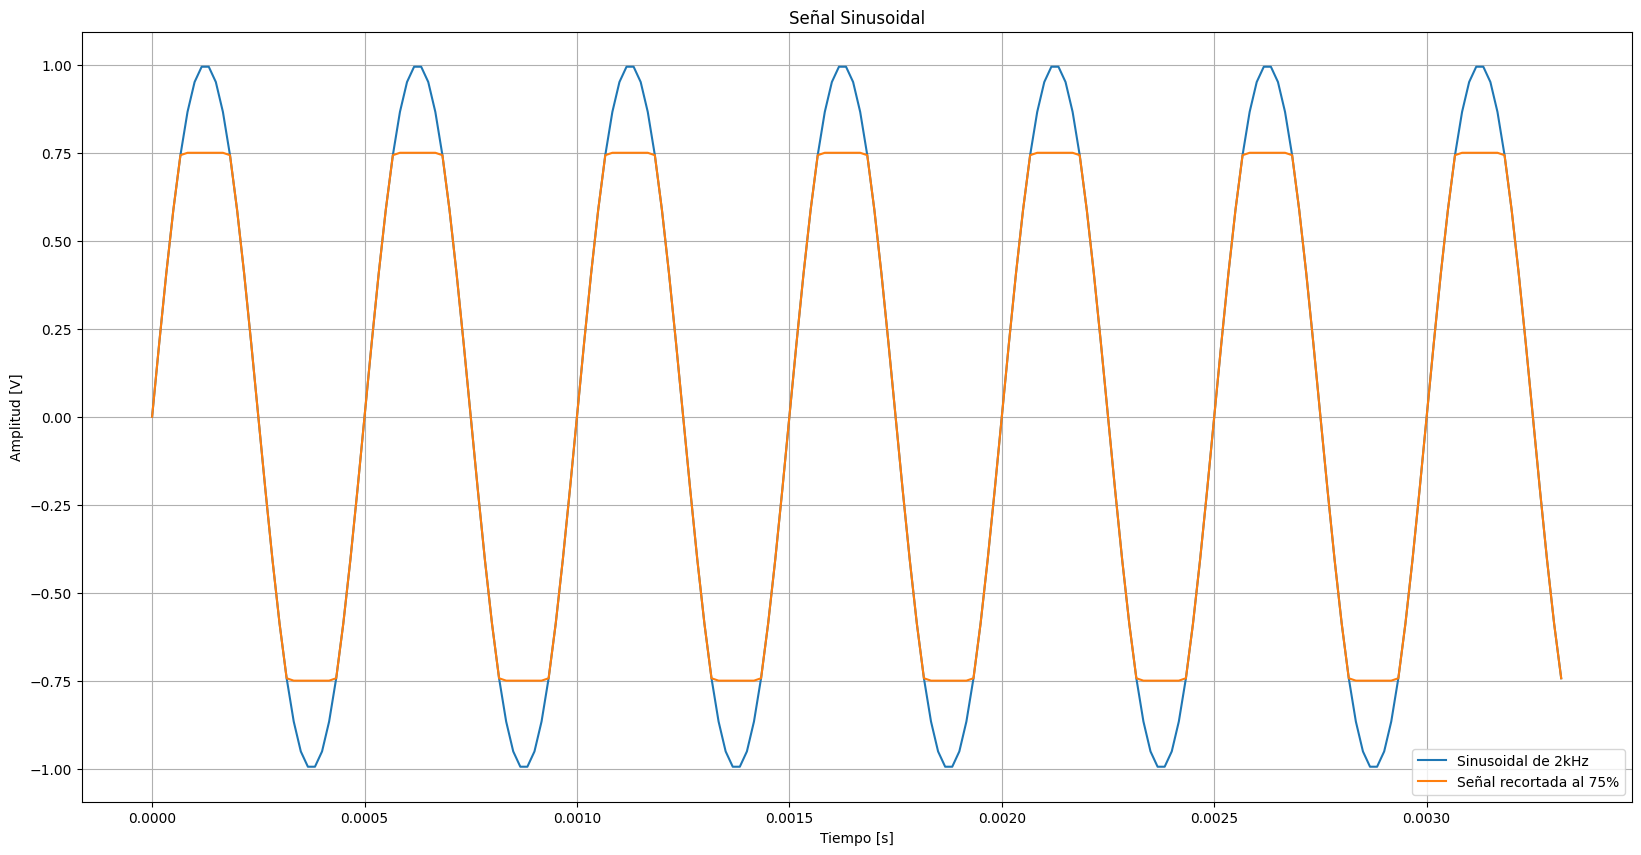

El tiempo entre muestras es 1.6666666666666667e-05 segundos
Potencia de la señal f4:  0.3687413898301593


In [68]:
# ------------------------------- ITEM 4 -------------------------------
# Misma señal pero recortada al 75% de su potencia 
# Defino mis variables
amplitud = 1
offset = 0
frecuencia = 2000 # 2kHz = 2000 Hz
fase = 0
N = 200 # Cantidad de muestras
fs = 60000

# Llamo a mi funcion
_,f4 = mi_funcion_sen_recortada(amplitud, offset, frecuencia, fase, N, fs)

plt.figure(figsize = (20,10))
plt.title("Señal Sinusoidal")

# Grafico la señal senoidal de 2KHz
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.plot(_,f1, '-', label = 'Sinusoidal de 2kHz')
plt.legend()

# Grafico la señal recortada
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.plot(_,f4, '-', label = 'Señal recortada al 75%')
plt.legend()
plt.grid()
plt.show()

# TIEMPO ENTRE MUESTRAS
Ts = 1/fs
print(f"El tiempo entre muestras es {Ts} segundos")

# Calculo la potenacia
x = calcular_potencia(f4)
print("Potencia de la señal f4: ", x)

<font color=green>**5.** *Señal cuadrada de 4kHz*<font>

En este caso, se utilizó una función de [SciPy](https://docs.scipy.org/doc/scipy/reference/signal.html#waveforms) para graficar la señal cuadrada. 

Una señal cuadrada tiene saltos abruptos entre sus niveles máximos y mínimos. Entonces, es esperable que su potencia sea mayor que la de una senoidal de la misma amplitud. 

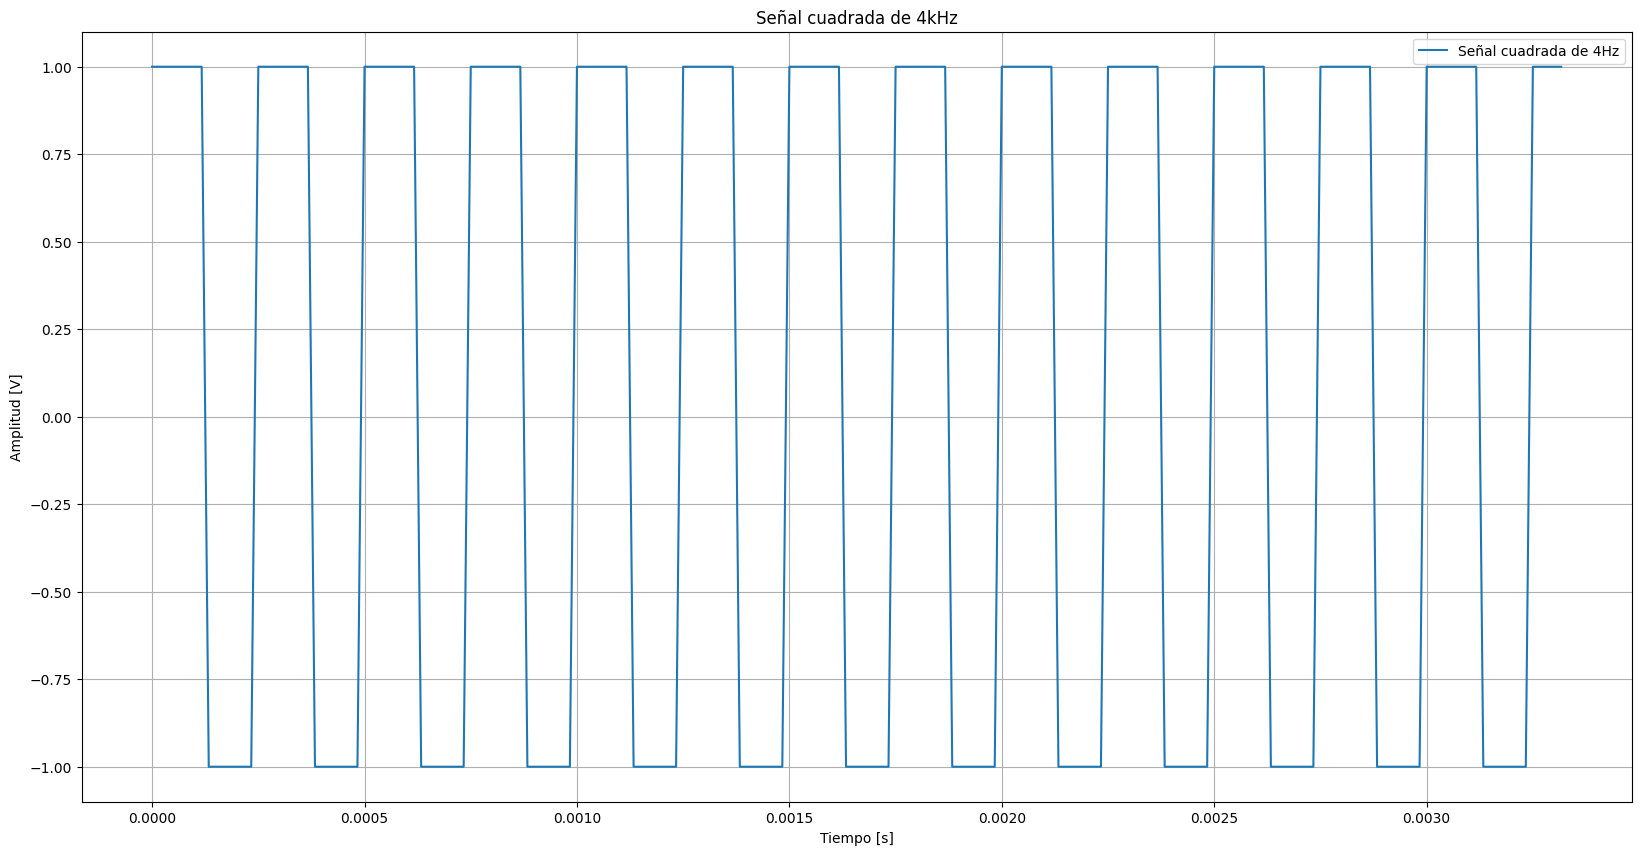

El tiempo entre muestras es 1.6666666666666667e-05 segundos
Potencia de la señal f5:  1.0


In [69]:
#%% ITEM 5
# ------------------------------- Señal cuadrada de 4kHz -------------------------------
# Defino mis variables
frecuencia = 4000
fs = 60000
N = 200 # Cantidad de muestras
offset = 0
fase = 0

# Llamo a mi funcion
_,f5 = mi_funcion_cuadrada(frecuencia, fs, N, offset, fase) # Comparo dos cosas de valores muy diferentes

# Grafico la señal cuadrada
plt.figure(figsize = (20,10))
plt.title('Señal cuadrada de 4kHz')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.plot(_,f5, label = 'Señal cuadrada de 4Hz')
plt.legend()
plt.grid()
plt.show()

# TIEMPO ENTRE MUESTRAS
Ts = 1/fs
print(f"El tiempo entre muestras es {Ts} segundos")

# Calculo la potenacia
x = calcular_potencia(f5)
print("Potencia de la señal f5: ", x)

<font color=green>**6.** *Pulso rectangular de 10ms*<font>

Un pulso muestra una energía finita concentrada en un intervalo de tiempo determinado. En este caso, ese intervalo son 10*ms*, es decir que la función vale cero siempre menos en ese tiempo que se le indica a la función. 

A diferencia de las otras señales, que son periódicas, para el pulso no se define potencia, sino que se calcula la energía total ($E = \sum (x[n])^2$). Se observó que la energía depende tanto de la amplitud como de la duración del pulso.


PULSO RECTANGULAR DE 10ms
[0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]


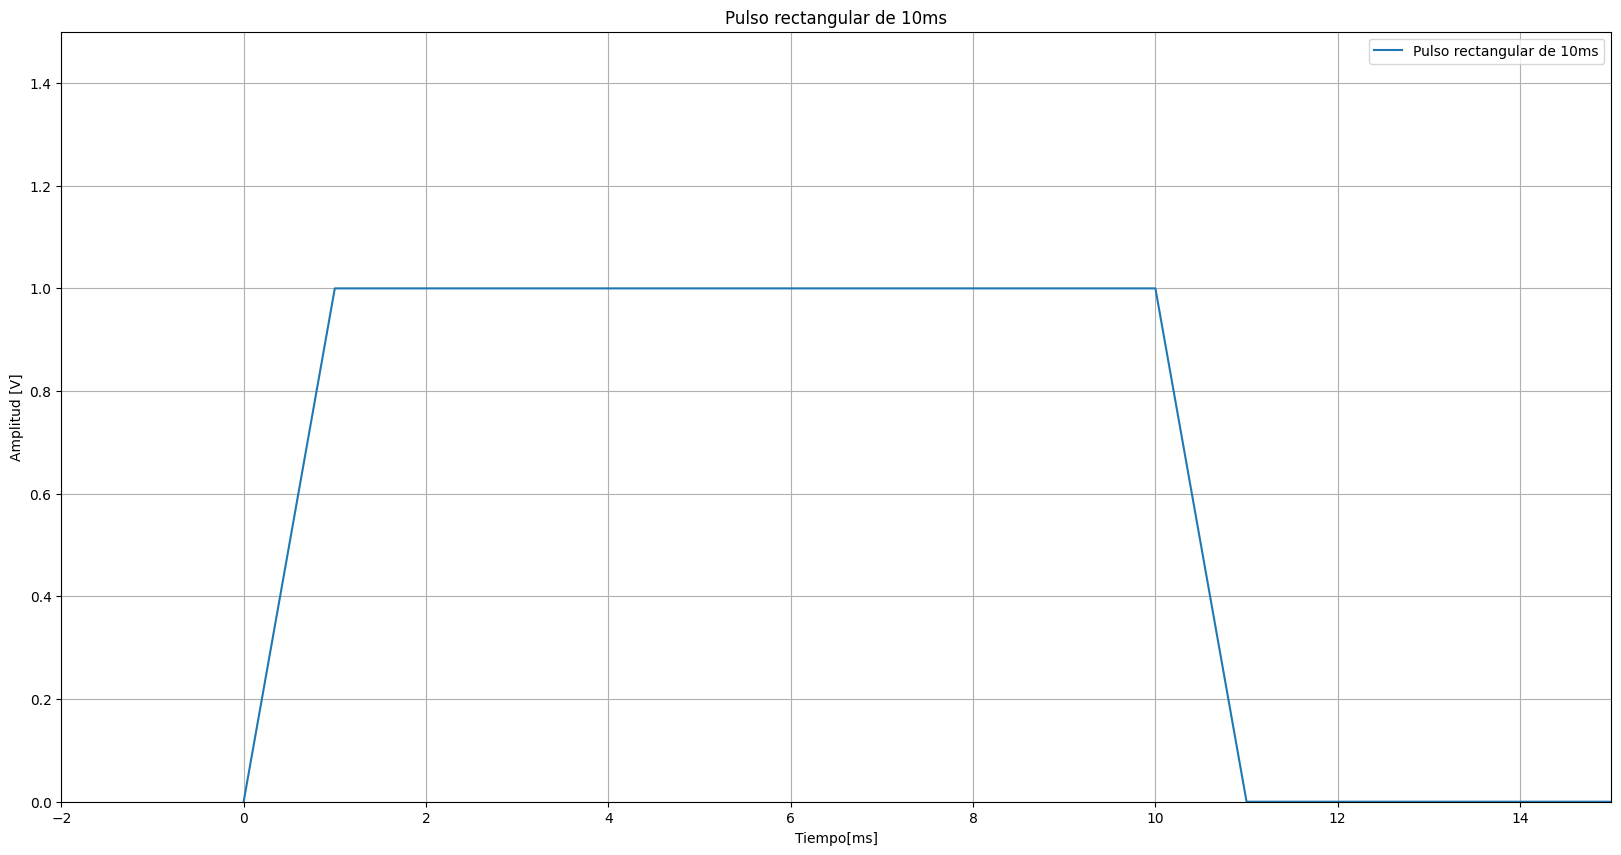

El tiempo entre muestras es 1.6666666666666667e-05 segundos
Energia de la señal f6:  10.0


In [70]:
# ------------------------------- ITEM 6 -------------------------------
# Pulso rectangular de 10ms
# Defino mis variables
t0 = 1 # Tiempo donde empieza el pulso
tf = 11 # Tiempo donde termina el pulso 
# --> Con este t0 y tf mi pulso rectangular dura 10ms
N = 200 # Cantidad de muestras
h = 1 # Altura del pulso 

# Llamo a mi funcion
f6 = mi_funcion_pulso(t0, tf, N, h)

# Grafico
plt.figure(figsize = (20,10))
plt.title('Pulso rectangular de 10ms')
plt.plot(f6, label = 'Pulso rectangular de 10ms')
# otra manera de graficar el pulso: 
# plt.stem(x)
plt.xlabel('Tiempo[ms]')
plt.ylabel('Amplitud [V]')
plt.axis([-2,15,0,1.5]) #Limites del grafico ([Xmin,Xmax,Ymin,Ymax]), si no se agrega este plt (axis) el programa por default busca mostrar todo el grafico completo
plt.legend()
plt.grid()
plt.show()

# TIEMPO ENTRE MUESTRAS
Ts = 1/fs
print(f"El tiempo entre muestras es {Ts} segundos")

# Calculo la energia
x = calcular_energia(f6)
print("Energia de la señal f6: ", x)

2) <font color=red><u> **Convolución entre señales</u><font>**

En este ejercicio se buscó obtener la salida de un sistema mediante el producto de convolución entre la señal de entrada $x[n]$ y la respuesta al impulso $h[n]=\delta[n] - \delta[n - 4]$. Entonces se calculó la salida $y[n]=x[n] * h[n]$ para las siguientes señales de entrada:

- $x[n]=cos(w_{0} \cdot n \cdot T_{s})$, expresando el resultado como un único coseno de la forma $A \cdot cos(w_{0} \cdot n \cdot T_{s} + \varphi)$
- $x[n]=\left(\frac{1}{2}\right)^n \cdot u[n]$
- $x[n]=u[n + 1] - u[n - 2]$

Para resolver cada uno de los productos de convolución, se utilizó la definición de convolución discreta (método de suma directa): 
$$
y[n]=\sum_{k=-\infty}^{+\infty} x[k] \cdot h[n - k]
$$

Y teniendo en cuenta la forma particular de $h[n]$ que son dos $\delta$, las cuales actúan como selectoras, se puede simplificar el cálculo como: 
$$
y[n]=x[n]-x[n - 4] 
$$

Esta expresión permite interpretar al sistema como la diferencia entre la señal original y una versión de la misma demorada 4 muestras. 

A continuación, se presentan los cálculos y los resultados obtenidos para cada caso...

In [71]:
from IPython.display import IFrame

# Mostrar el PDF en un "iframe" dentro de la notebook
IFrame("Ejercicio 2.pdf", width="100%", height="800")


# <u>**Conclusiones**</u>

La síntesis y el hecho de graficar señales me permitió comprender como los distintos parámetros - amplitud, desfazaje, modulacion y recorte - afectan a la forma de onda y a sus propiedades de energía o potencia. Se pudo observar cómo una misma señal se comporta de manera distinta al variar dichos parámetros. 

En relación con la energía de la señal en tiempo discreto, se calculó la suma de los cuadrados de las muestras: $E = \sum_{n = 0}^{N - 1} |x[n]|^2$ 

Este valor depende de la cantidad de muestras consideradas (*N*) y, en consecuencia, del tiempo total de observación. Cuanto mayor es la ventana de análisis (más muestras), mayor será la energía acumulada, ya que se estan sumando mas contribuciones. Por otro lado, el cálculo de la potencia promedio resulta útil para señales de duración finita o periódicas y se relaciona con el cuadrado de la amplitud. Entonces, la potencia se incrementa proporcionalmente a la amplitud de la señal (${potencia} = \frac{(amplitud)^2}{2}$).

# <u>**Autoevaluación del aprendizaje**</u>

Para concluir con el informe se realizó una autoevaluacion del aprendizaje.

Durante la realización de las actividades propuestas pude afianzar algunos conceptos de teoría y, al mismo tiempo, me surgieron nuevas dudas. Siento que todavía necesito profundizar en algunos aspectos teóricos debido a la cantidad de contenido nuevo en poco tiempo. 

En cuanto a la programación, me sentí bastante cómoda, los códigos estuvieron dentro de un nivel de dificultad manejable, y las funciones de *numpy* y *SciPy* me resultaron muy útiles para resolver los ejercicios de manera eficiente. 

Por último, la *IA* fue de gran ayuda en: 
- Implementacion de código: facilitando la traduccion de teoría a práctica.
- Conceptos teóricos: ayudando a comprender mejor temas específicos que requerían mayor claridad.


# <u>**Cambios**</u>

